In [1]:
## Compute daily returns — daily_return = nav_t / nav_t-1 − 1 for all 40 schemes. Validate distribution looks reasonable.  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_nav = pd.read_csv("C:/MutualFundProject/data/raw/02_nav_history.csv")

df_nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
df_nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [4]:
df_nav['date'] = pd.to_datetime(df_nav['date'], errors='coerce')
df_nav['nav'] = pd.to_numeric(df_nav['nav'], errors='coerce')

df_nav = df_nav.dropna(subset=['amfi_code','date','nav'])
df_nav = df_nav.sort_values(['amfi_code','date'])

In [5]:
print(df_nav.dtypes)
print(df_nav.shape)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object
(46000, 3)


In [6]:
df_nav['daily_return'] = (
    df_nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [7]:
df_nav['daily_return'] = (
    df_nav['nav'] /
    df_nav.groupby('amfi_code')['nav'].shift(1)
) - 1

In [8]:
scheme_count = df_nav['amfi_code'].nunique()

print("Number of schemes:", scheme_count)

Number of schemes: 40


In [9]:
df_nav.groupby('amfi_code')['daily_return'].count().describe()

count      40.0
mean     1149.0
std         0.0
min      1149.0
25%      1149.0
50%      1149.0
75%      1149.0
max      1149.0
Name: daily_return, dtype: float64

In [10]:
df_nav[['amfi_code', 'date', 'nav', 'daily_return']].head(20)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [11]:
returns = df_nav['daily_return'].dropna()

print(returns.describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


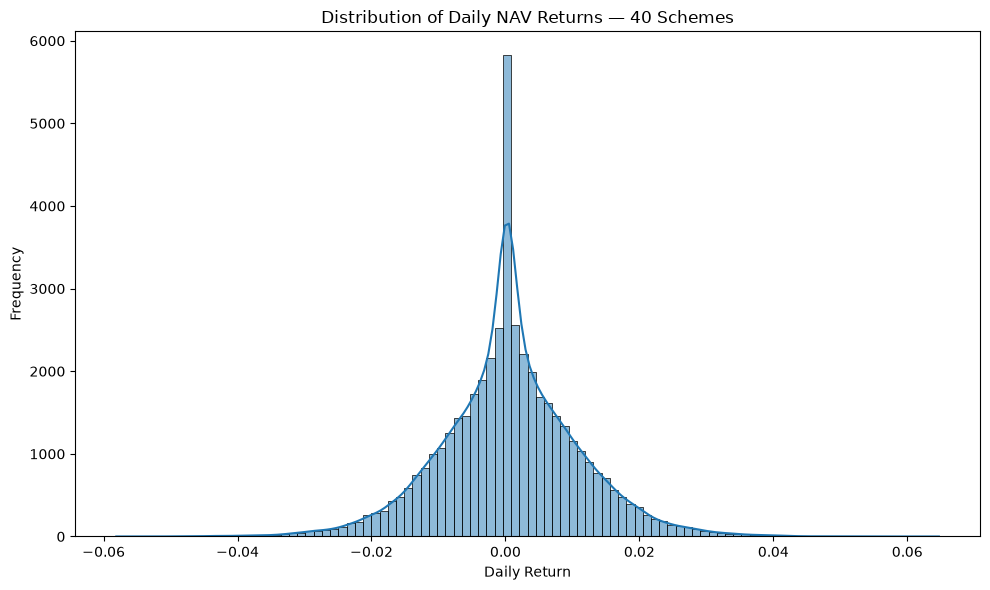

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    returns,
    bins=100,
    kde=True
)

plt.title("Distribution of Daily NAV Returns — 40 Schemes")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

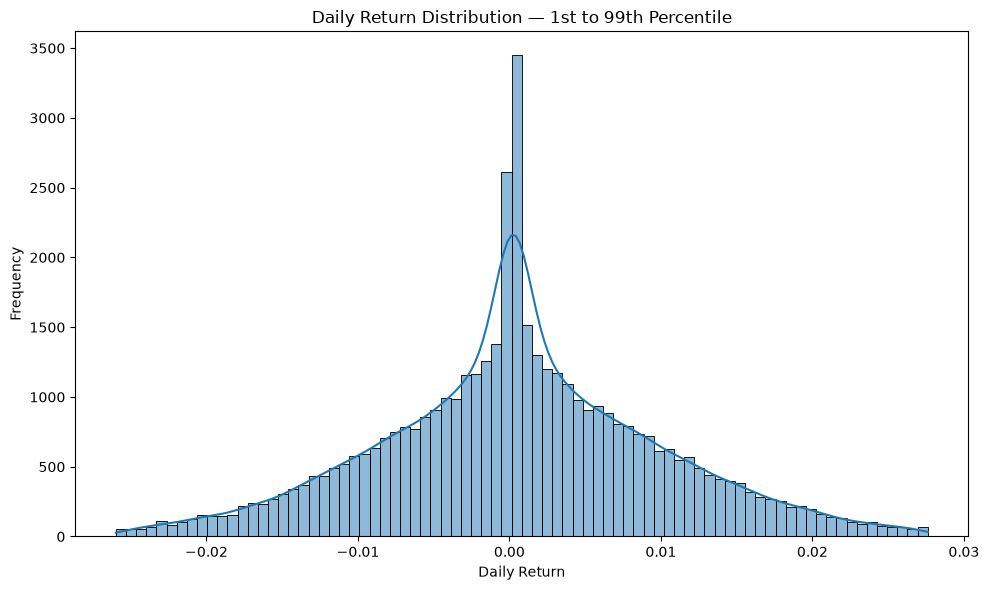

In [13]:
lower = returns.quantile(0.01)
upper = returns.quantile(0.99)

plt.figure(figsize=(10, 6))

sns.histplot(
    returns[(returns >= lower) & (returns <= upper)],
    bins=80,
    kde=True
)

plt.title("Daily Return Distribution — 1st to 99th Percentile")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [14]:
df_nav.nlargest(10, 'daily_return')[
    ['amfi_code', 'date', 'nav', 'daily_return']
]

,amfi_code,date,nav,daily_return
2895,119598,2024-04-15,189.0742,0.064713
20126,118634,2024-03-19,110.5401,0.059304
33957,101207,2024-05-01,65.5882,0.054851
3716,119599,2023-01-10,153.2221,0.053320
3982,119599,2024-01-17,136.8239,0.051811
2305,119598,2022-01-10,96.0964,0.051113
2521,119598,2022-11-08,123.9704,0.049051
45082,149324,2022-11-23,98.3696,0.048490
2506,119598,2022-10-18,122.2757,0.048454
3241,119598,2025-08-12,200.8460,0.047123


In [15]:
df_nav.nsmallest(10, 'daily_return')[
    ['amfi_code', 'date', 'nav', 'daily_return']
]

,amfi_code,date,nav,daily_return
19674,118634,2022-06-24,67.2534,-0.058102
33667,101207,2023-03-22,56.8326,-0.051847
19852,118634,2023-03-01,113.5801,-0.050335
45312,149324,2023-10-11,111.8155,-0.048870
34310,101207,2025-09-08,62.3200,-0.048634
31304,119095,2022-12-23,73.9946,-0.048367
20233,118634,2024-08-15,114.5168,-0.048305
31807,119095,2024-11-27,78.1317,-0.046524
4198,119599,2024-11-14,112.8996,-0.045429
9770,125498,2024-03-11,131.4556,-0.045218


In [16]:
df_nav[
    (df_nav['daily_return'] > 0.20) |
    (df_nav['daily_return'] < -0.20)
][
    ['amfi_code', 'date', 'nav', 'daily_return']
]

,amfi_code,date,nav,daily_return


In [17]:
scheme_stats = (
    df_nav.groupby('amfi_code')['daily_return']
    .agg(
        count='count',
        mean='mean',
        std='std',
        min='min',
        median='median',
        max='max'
    )
    .reset_index()
)

scheme_stats

,amfi_code,count,mean,std,min,median,max
0,100016,1149,0.000142,0.009164,-0.024744,-0.000070,0.032145
1,100025,1149,0.000170,0.002460,-0.008188,0.000099,0.008837
2,100033,1149,0.001080,0.011929,-0.044238,0.001086,0.041954
3,101206,1149,0.000852,0.009177,-0.038121,0.000808,0.033956
4,101207,1149,0.000424,0.016251,-0.051847,0.000182,0.054851
5,101208,1149,0.000242,0.000319,-0.000766,0.000249,0.001247
6,102885,1149,0.000674,0.008086,-0.021104,0.000632,0.025565
7,102886,1149,0.000110,0.011424,-0.036695,0.000472,0.040745
8,102887,1149,0.000645,0.009927,-0.031271,0.000390,0.032386
9,118632,1149,0.000865,0.008913,-0.028490,0.000969,0.028218


In [18]:
scheme_stats.sort_values('std', ascending=False)

,amfi_code,count,mean,std,min,median,max
4,101207,1149,0.000424,0.016251,-0.051847,0.000182,0.054851
11,118634,1149,0.000707,0.015901,-0.058102,0.000921,0.059304
21,119598,1149,0.001201,0.015837,-0.045180,0.001250,0.064713
17,119095,1149,0.000182,0.015790,-0.048367,0.000172,0.043110
22,119599,1149,0.000201,0.015717,-0.045429,0.000339,0.053320
39,149324,1149,0.001194,0.015648,-0.048870,0.000987,0.048490
16,119094,1149,0.001027,0.012225,-0.040755,0.000613,0.041591
25,120505,1149,0.001161,0.012152,-0.038418,0.000955,0.040812
2,100033,1149,0.001080,0.011929,-0.044238,0.001086,0.041954
33,125498,1149,0.000477,0.011561,-0.045218,0.000753,0.036193


In [19]:
scheme_stats.sort_values('std')

,amfi_code,count,mean,std,min,median,max
27,120507,1149,0.000268,0.000311,-0.000666,0.000267,0.001197
5,101208,1149,0.000242,0.000319,-0.000766,0.000249,0.001247
31,120844,1149,0.000256,0.000323,-0.000704,0.000258,0.001254
1,100025,1149,0.000170,0.002460,-0.008188,0.000099,0.008837
18,119120,1149,0.000222,0.002499,-0.007690,0.000226,0.008163
13,118636,1149,0.000202,0.002511,-0.008883,0.000154,0.007708
6,102885,1149,0.000674,0.008086,-0.021104,0.000632,0.025565
12,118635,1149,0.000600,0.008179,-0.025466,0.000494,0.030547
28,120841,1149,0.000522,0.008481,-0.023779,0.000582,0.028580
19,119551,1149,0.000917,0.008656,-0.027680,0.000940,0.035096


In [20]:
print("Skewness:", returns.skew())
print("Kurtosis:", returns.kurtosis())

Skewness: 0.042677821268501254
Kurtosis: 1.367312233224025


In [21]:
df_nav.to_csv(
    "C:/MutualFundProject/data/processed/Performance_analytics_CSV_file/01_nav_daily_returns.csv",
    index=False
)

In [22]:
print("Schemes:", df_nav['amfi_code'].nunique())
print("Rows:", len(df_nav))
print("Missing returns:", df_nav['daily_return'].isna().sum())
print("Mean:", returns.mean())
print("Std:", returns.std())
print("Min:", returns.min())
print("Max:", returns.max())
print("Skewness:", returns.skew())
print("Kurtosis:", returns.kurtosis())

Schemes: 40
Rows: 46000
Missing returns: 40
Mean: 0.0006310517590547711
Std: 0.010290414788248919
Min: -0.058102013949189124
Max: 0.06471309359097144
Skewness: 0.042677821268501254
Kurtosis: 1.367312233224025


In [23]:
## Compute CAGR for 1yr, 3yr, 5yr — CAGR = (NAV_end / NAV_start) ^ (1/n) − 1. Build a comparison table across all funds.

In [24]:
import pandas as pd
import numpy as np

df_nav = pd.read_csv("C:/MutualFundProject/data/raw/02_nav_history.csv")

df_nav['date'] = pd.to_datetime(df_nav['date'], errors='coerce')
df_nav['nav'] = pd.to_numeric(df_nav['nav'], errors='coerce')

df_nav = (
    df_nav
    .dropna(subset=['amfi_code', 'date', 'nav'])
    .sort_values(['amfi_code', 'date'])
)

print("Number of schemes:", df_nav['amfi_code'].nunique())

Number of schemes: 40


In [25]:
print("Start date:", df_nav['date'].min())
print("End date:", df_nav['date'].max())

Start date: 2022-01-03 00:00:00
End date: 2026-05-29 00:00:00


In [26]:
def calculate_cagr(nav_start, nav_end, years):
    if pd.isna(nav_start) or pd.isna(nav_end):
        return np.nan

    if nav_start <= 0 or nav_end <= 0:
        return np.nan

    return (nav_end / nav_start) ** (1 / years) - 1

In [27]:
latest_date = df_nav['date'].max()

periods = {
    '1Y': 1,
    '3Y': 3,
    '5Y': 5
}

results = []

for scheme, group in df_nav.groupby('amfi_code'):

    group = group.sort_values('date')

    end_row = group.iloc[-1]
    end_date = end_row['date']
    end_nav = end_row['nav']

    row = {
        'amfi_code': scheme,
        'end_date': end_date,
        'end_nav': end_nav
    }

    for label, years in periods.items():

        target_date = end_date - pd.DateOffset(years=years)

        # NAV closest to target date
        idx = (group['date'] - target_date).abs().idxmin()
        start_row = group.loc[idx]

        start_nav = start_row['nav']
        start_date = start_row['date']

        cagr = calculate_cagr(
            start_nav,
            end_nav,
            years
        )

        row[f'{label}_start_date'] = start_date
        row[f'{label}_start_nav'] = start_nav
        row[f'{label}_cagr'] = cagr

    results.append(row)

cagr_table = pd.DataFrame(results)

In [28]:
comparison_table = cagr_table[
    [
        'amfi_code',
        '1Y_start_date',
        '1Y_start_nav',
        '1Y_cagr',
        '3Y_start_date',
        '3Y_start_nav',
        '3Y_cagr',
        '5Y_start_date',
        '5Y_start_nav',
        '5Y_cagr'
    ]
].copy()

In [29]:
for col in ['1Y_cagr', '3Y_cagr', '5Y_cagr']:
    comparison_table[col] = comparison_table[col] * 100

In [30]:
final_cagr_table = comparison_table[
    ['amfi_code', '1Y_cagr', '3Y_cagr', '5Y_cagr']
].copy()

final_cagr_table.columns = [
    'AMFI Code',
    '1Y CAGR (%)',
    '3Y CAGR (%)',
    '5Y CAGR (%)'
]

final_cagr_table

,AMFI Code,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%)
0,100016,-2.224271,1.292649,2.316843
1,100025,3.704969,3.916390,3.912653
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
4,101207,-23.986032,-4.152381,6.953336
5,101208,7.236645,6.315784,5.705734
6,102885,20.207704,19.667262,15.878823
7,102886,-16.797481,-0.767406,1.030350
8,102887,13.583135,25.556188,14.678110
9,118632,33.981048,22.652360,20.881118


In [31]:
top_3y = final_cagr_table.sort_values(
    '3Y CAGR (%)',
    ascending=False
)

top_3y.head(10)

,AMFI Code,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%)
16,119094,22.261065,35.111802,24.445309
34,148567,20.360678,34.000916,26.799277
24,120504,13.064279,32.487429,20.234028
2,100033,53.232396,32.442459,26.074068
25,120505,29.604659,31.777537,28.376762
19,119551,60.437341,30.456524,22.384873
30,120843,26.657082,29.582770,26.742494
36,148569,39.751761,29.178902,27.629860
3,101206,47.924120,28.967695,20.442730
39,149324,65.138719,27.000427,27.917430


In [32]:
final_cagr_table.sort_values(
    '1Y CAGR (%)',
    ascending=False
).head(10)

,AMFI Code,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%)
21,119598,82.776059,26.669922,28.033224
39,149324,65.138719,27.000427,27.917430
19,119551,60.437341,30.456524,22.384873
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
26,120506,41.819048,18.421997,14.888597
36,148569,39.751761,29.178902,27.629860
9,118632,33.981048,22.652360,20.881118
25,120505,29.604659,31.777537,28.376762
32,125497,28.675358,18.434489,16.555919


In [33]:
final_cagr_table.sort_values(
    '5Y CAGR (%)',
    ascending=False
).head(10)

,AMFI Code,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%)
25,120505,29.604659,31.777537,28.376762
21,119598,82.776059,26.669922,28.033224
39,149324,65.138719,27.000427,27.917430
36,148569,39.751761,29.178902,27.629860
34,148567,20.360678,34.000916,26.799277
30,120843,26.657082,29.582770,26.742494
2,100033,53.232396,32.442459,26.074068
38,149323,21.481222,26.869991,25.611807
16,119094,22.261065,35.111802,24.445309
19,119551,60.437341,30.456524,22.384873


In [34]:
for col in ['1Y CAGR (%)', '3Y CAGR (%)', '5Y CAGR (%)']:
    print(f"\n{col}")
    print(final_cagr_table[col].describe())


1Y CAGR (%)
count    40.000000
mean     19.428520
std      22.912276
min     -42.797615
25%       7.377949
50%      17.474125
75%      27.161651
max      82.776059
Name: 1Y CAGR (%), dtype: float64

3Y CAGR (%)
count    40.000000
mean     16.414715
std      12.206752
min     -11.705807
25%       6.600925
50%      18.233102
75%      26.902600
max      35.111802
Name: 3Y CAGR (%), dtype: float64

5Y CAGR (%)
count    40.000000
mean     14.541077
std       8.901844
min       1.030350
25%       6.013784
50%      14.476118
75%      21.257057
max      28.376762
Name: 5Y CAGR (%), dtype: float64


In [35]:
final_cagr_table[
    (final_cagr_table['1Y CAGR (%)'].abs() > 50) |
    (final_cagr_table['3Y CAGR (%)'].abs() > 50) |
    (final_cagr_table['5Y CAGR (%)'].abs() > 50)
]

,AMFI Code,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%)
2,100033,53.232396,32.442459,26.074068
19,119551,60.437341,30.456524,22.384873
21,119598,82.776059,26.669922,28.033224
39,149324,65.138719,27.000427,27.917430


In [36]:
comparison_table.sort_values(
    '1Y_cagr',
    ascending=False
).head(10)

,amfi_code,1Y_start_date,1Y_start_nav,1Y_cagr,3Y_start_date,3Y_start_nav,3Y_cagr,5Y_start_date,5Y_start_nav,5Y_cagr
21,119598,2025-05-29,169.1715,82.776059,2023-05-29,152.1339,26.669922,2022-01-03,89.8738,28.033224
39,149324,2025-05-29,169.4037,65.138719,2023-05-29,136.5703,27.000427,2022-01-03,81.6814,27.917430
19,119551,2025-05-29,93.0716,60.437341,2023-05-29,67.2551,30.456524,2022-01-03,54.3856,22.384873
2,100033,2025-05-29,223.1951,53.232396,2023-05-29,147.2155,32.442459,2022-01-03,107.3758,26.074068
3,101206,2025-05-29,522.7639,47.924120,2023-05-29,360.4971,28.967695,2022-01-03,305.0996,20.442730
26,120506,2025-05-29,285.1667,41.819048,2023-05-29,243.5209,18.421997,2022-01-03,202.0453,14.888597
36,148569,2025-05-29,69.9408,39.751761,2023-05-29,45.3433,29.178902,2022-01-03,28.8620,27.629860
9,118632,2025-05-29,82.5157,33.981048,2023-05-29,59.9173,22.652360,2022-01-03,42.8339,20.881118
25,120505,2025-05-29,365.5455,29.604659,2023-05-29,207.0322,31.777537,2022-01-03,135.8720,28.376762
32,125497,2025-05-29,936.4319,28.675358,2023-05-29,725.3323,18.434489,2022-01-03,560.1443,16.555919


In [37]:
for years in [1, 3, 5]:

    required_date = df_nav['date'].max() - pd.DateOffset(years=years)

    print(
        f"{years}Y required start date:",
        required_date
    )

    print(
        "Available from:",
        df_nav['date'].min()
    )

1Y required start date: 2025-05-29 00:00:00
Available from: 2022-01-03 00:00:00
3Y required start date: 2023-05-29 00:00:00
Available from: 2022-01-03 00:00:00
5Y required start date: 2021-05-29 00:00:00
Available from: 2022-01-03 00:00:00


In [38]:
final_cagr_table.to_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/02_fund_cagr_comparison.csv",
    index=False
)

In [39]:
## Sharpe Ratio — (Rp − Rf) / Std(Rp) × √252. Use Rf = 6.5% (RBI repo rate proxy). Rank all 40 funds.

In [40]:
RF_ANNUAL = 0.065
TRADING_DAYS = 252

In [41]:
import pandas as pd
import numpy as np

df_nav = pd.read_csv("C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/01_nav_daily_returns.csv")

df_nav['date'] = pd.to_datetime(df_nav['date'])

df_nav = df_nav.sort_values(
    ['amfi_code', 'date']
)

df_nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [42]:
rf_daily = (1 + RF_ANNUAL) ** (1 / 252) - 1

print("Daily risk-free rate:", rf_daily)

Daily risk-free rate: 0.00024993122427763304


In [43]:
sharpe_table = (
    df_nav
    .dropna(subset=['daily_return'])
    .groupby('amfi_code')['daily_return']
    .agg(
        mean_daily_return='mean',
        daily_std='std',
        observations='count'
    )
    .reset_index()
)

In [44]:
sharpe_table['sharpe_ratio'] = (
    (sharpe_table['mean_daily_return'] - rf_daily)
    / sharpe_table['daily_std']
) * np.sqrt(252)

In [45]:
sharpe_table = sharpe_table.sort_values(
    'sharpe_ratio',
    ascending=False
).reset_index(drop=True)

sharpe_table['rank'] = (
    sharpe_table.index + 1
)

In [46]:
final_sharpe = sharpe_table[
    [
        'rank',
        'amfi_code',
        'mean_daily_return',
        'daily_std',
        'sharpe_ratio',
        'observations'
    ]
]

In [47]:
final_sharpe = final_sharpe.round({
    'mean_daily_return': 6,
    'daily_std': 6,
    'sharpe_ratio': 3
})

final_sharpe

,rank,amfi_code,mean_daily_return,daily_std,sharpe_ratio,observations
0,1,148567,0.001074,0.008941,1.463,1149
1,2,120843,0.001082,0.010008,1.319,1149
2,3,148569,0.001124,0.011134,1.246,1149
3,4,119551,0.000917,0.008656,1.223,1149
4,5,120505,0.001161,0.012152,1.191,1149
5,6,149323,0.001055,0.011179,1.143,1149
6,7,100033,0.001080,0.011929,1.104,1149
7,8,118632,0.000865,0.008913,1.096,1149
8,9,101206,0.000852,0.009177,1.041,1149
9,10,120504,0.000843,0.009048,1.041,1149


In [48]:
print("Number of funds:", final_sharpe['amfi_code'].nunique())

Number of funds: 40


In [49]:
print("Top 10 funds:")
display(final_sharpe.head(10))

Top 10 funds:


,rank,amfi_code,mean_daily_return,daily_std,sharpe_ratio,observations
0,1,148567,0.001074,0.008941,1.463,1149
1,2,120843,0.001082,0.010008,1.319,1149
2,3,148569,0.001124,0.011134,1.246,1149
3,4,119551,0.000917,0.008656,1.223,1149
4,5,120505,0.001161,0.012152,1.191,1149
5,6,149323,0.001055,0.011179,1.143,1149
6,7,100033,0.001080,0.011929,1.104,1149
7,8,118632,0.000865,0.008913,1.096,1149
8,9,101206,0.000852,0.009177,1.041,1149
9,10,120504,0.000843,0.009048,1.041,1149


In [50]:
print("Bottom 10 funds:")
display(final_sharpe.tail(10))

Bottom 10 funds:


,rank,amfi_code,mean_daily_return,daily_std,sharpe_ratio,observations
30,31,120842,0.000312,0.011273,0.087,1149
31,32,119092,0.000275,0.008788,0.045,1149
32,33,119599,0.000201,0.015717,-0.049,1149
33,34,119095,0.000182,0.015790,-0.068,1149
34,35,119120,0.000222,0.002499,-0.176,1149
35,36,100016,0.000142,0.009164,-0.188,1149
36,37,102886,0.000110,0.011424,-0.195,1149
37,38,118636,0.000202,0.002511,-0.306,1149
38,39,101208,0.000242,0.000319,-0.417,1149
39,40,100025,0.000170,0.002460,-0.515,1149


In [51]:
print(
    final_sharpe[
        final_sharpe['sharpe_ratio'].isna() |
        np.isinf(final_sharpe['sharpe_ratio'])
    ]
)

Empty DataFrame
Columns: [rank, amfi_code, mean_daily_return, daily_std, sharpe_ratio, observations]
Index: []


In [52]:
final_sharpe.to_csv(
    "C:/MutualFundproject/data/processed/performance_Analytics_CSV_file/03_fund_sharpe_ranking.csv",
    index=False
)

In [53]:
## Sortino Ratio — same formula but denominator uses only downside standard deviation (negative return days only).

In [54]:
import pandas as pd
import numpy as np

df_nav = pd.read_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/01_nav_daily_returns.csv"
)

df_nav['date'] = pd.to_datetime(df_nav['date'])

df_nav = df_nav.sort_values(
    ['amfi_code', 'date']
)

In [55]:
RF_ANNUAL = 0.065
TRADING_DAYS = 252

rf_daily = (1 + RF_ANNUAL) ** (1 / TRADING_DAYS) - 1

print("Daily risk-free rate:", rf_daily)

Daily risk-free rate: 0.00024993122427763304


In [56]:
negative_returns = df_nav[
    df_nav['daily_return'] < 0
]

In [57]:
downside_stats = (
    negative_returns
    .groupby('amfi_code')['daily_return']
    .agg(
        downside_std='std',
        negative_days='count'
    )
    .reset_index()
)

downside_stats.head()

,amfi_code,downside_std,negative_days
0,100016,0.005261,579
1,100025,0.001481,549
2,100033,0.007133,538
3,101206,0.005238,539
4,101207,0.009555,568


In [58]:
return_stats = (
    df_nav
    .dropna(subset=['daily_return'])
    .groupby('amfi_code')['daily_return']
    .agg(
        mean_daily_return='mean',
        total_days='count'
    )
    .reset_index()
)

In [59]:
sortino_table = return_stats.merge(
    downside_stats,
    on='amfi_code',
    how='left'
)

sortino_table.head()

,amfi_code,mean_daily_return,total_days,downside_std,negative_days
0,100016,0.000142,1149,0.005261,579
1,100025,0.000170,1149,0.001481,549
2,100033,0.001080,1149,0.007133,538
3,101206,0.000852,1149,0.005238,539
4,101207,0.000424,1149,0.009555,568


In [60]:
sortino_table['sortino_ratio'] = (
    (sortino_table['mean_daily_return'] - rf_daily)
    / sortino_table['downside_std']
) * np.sqrt(252)

In [61]:
sortino_table = sortino_table.sort_values(
    'sortino_ratio',
    ascending=False
).reset_index(drop=True)

sortino_table['rank'] = (
    sortino_table.index + 1
)

In [62]:
final_sortino = sortino_table[
    [
        'rank',
        'amfi_code',
        'mean_daily_return',
        'downside_std',
        'negative_days',
        'sortino_ratio'
    ]
].copy()

In [63]:
final_sortino = final_sortino.round({
    'mean_daily_return': 6,
    'downside_std': 6,
    'sortino_ratio': 3
})

final_sortino

,rank,amfi_code,mean_daily_return,downside_std,negative_days,sortino_ratio
0,1,148567,0.001074,0.005428,506,2.409
1,2,120843,0.001082,0.005531,534,2.387
2,3,148569,0.001124,0.006404,545,2.167
3,4,119551,0.000917,0.004887,518,2.166
4,5,120505,0.001161,0.007067,539,2.047
5,6,120507,0.000268,0.000147,225,1.919
6,7,149323,0.001055,0.006750,526,1.894
7,8,118632,0.000865,0.005211,532,1.875
8,9,100033,0.001080,0.007133,538,1.847
9,10,120504,0.000843,0.005145,517,1.830


In [64]:
print(
    "Number of funds:",
    final_sortino['amfi_code'].nunique()
)

Number of funds: 40


In [65]:
print(
    final_sortino[
        final_sortino['sortino_ratio'].isna() |
        np.isinf(final_sortino['sortino_ratio'])
    ]
)

Empty DataFrame
Columns: [rank, amfi_code, mean_daily_return, downside_std, negative_days, sortino_ratio]
Index: []


In [66]:
top_10_sortino = final_sortino.head(10)

top_10_sortino

,rank,amfi_code,mean_daily_return,downside_std,negative_days,sortino_ratio
0,1,148567,0.001074,0.005428,506,2.409
1,2,120843,0.001082,0.005531,534,2.387
2,3,148569,0.001124,0.006404,545,2.167
3,4,119551,0.000917,0.004887,518,2.166
4,5,120505,0.001161,0.007067,539,2.047
5,6,120507,0.000268,0.000147,225,1.919
6,7,149323,0.001055,0.006750,526,1.894
7,8,118632,0.000865,0.005211,532,1.875
8,9,100033,0.001080,0.007133,538,1.847
9,10,120504,0.000843,0.005145,517,1.830


In [67]:
final_sortino.to_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/04_fund_sortino_ranking.csv",
    index=False
)

In [68]:
## Alpha and Beta — OLS regression of fund returns on Nifty 100 returns using scipy.stats.linregress. Alpha = intercept × 252.

In [69]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

df_fund = pd.read_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/01_nav_daily_returns.csv"
)

df_fund['date'] = pd.to_datetime(df_fund['date'])

df_fund = df_fund.dropna(
    subset=['daily_return']
)

df_fund = df_fund.sort_values(
    ['amfi_code', 'date']
)

In [70]:
df_nifty = pd.read_csv(
    "C:/MutualFundProject/data/raw/nifty100.csv"
)

df_nifty['date'] = pd.to_datetime(
    df_nifty['date']
)

df_nifty['close_value'] = pd.to_numeric(
    df_nifty['close_value'],
    errors='coerce'
)

df_nifty = df_nifty.sort_values('date')

In [77]:
df_nifty['nifty100_return'] = (
    df_nifty['close_value'].pct_change()
)

In [78]:
df_nifty = df_nifty.dropna(
    subset=['nifty100_return']
)

In [79]:
df_reg = df_fund.merge(
    df_nifty[['date', 'nifty100_return']],
    on='date',
    how='inner'
)

In [80]:
print(df_reg.shape)
print(df_reg[['date', 'daily_return', 'nifty100_return']].head())

(45960, 5)
        date  daily_return  nifty100_return
0 2022-01-04     -0.010306        -0.013540
1 2022-01-05      0.012865         0.004003
2 2022-01-06     -0.011377        -0.002935
3 2022-01-07     -0.001210         0.006150
4 2022-01-10     -0.008639        -0.008351


In [81]:
results = []

In [82]:
for scheme, group in df_reg.groupby('amfi_code'):

    group = group.dropna(
        subset=['daily_return', 'nifty100_return']
    )

    x = group['nifty100_return']
    y = group['daily_return']

    regression = linregress(x, y)

    beta = regression.slope
    alpha_daily = regression.intercept
    r_value = regression.rvalue
    p_value = regression.pvalue
    std_err = regression.stderr

    alpha_annual = alpha_daily * 252

    r_squared = r_value ** 2

    results.append({
        'amfi_code': scheme,
        'alpha_daily': alpha_daily,
        'alpha_annual': alpha_annual,
        'beta': beta,
        'r_squared': r_squared,
        'p_value': p_value,
        'std_error': std_err,
        'observations': len(group)
    })

In [83]:
alpha_beta = pd.DataFrame(results)

In [84]:
alpha_beta['alpha_annual_pct'] = (
    alpha_beta['alpha_annual'] * 100
)

In [85]:
alpha_beta['alpha_annual_pct'] = (
    alpha_beta['alpha_annual'] * 100
)

In [86]:
alpha_beta = alpha_beta.sort_values(
    'alpha_annual',
    ascending=False
).reset_index(drop=True)

In [87]:
alpha_beta['alpha_rank'] = (
    alpha_beta.index + 1
)

In [88]:
final_alpha_beta = alpha_beta[
    [
        'alpha_rank',
        'amfi_code',
        'alpha_annual_pct',
        'beta',
        'r_squared',
        'p_value',
        'observations'
    ]
].copy()

final_alpha_beta = final_alpha_beta.round({
    'alpha_annual_pct': 2,
    'beta': 3,
    'r_squared': 3,
    'p_value': 4
})

final_alpha_beta

,alpha_rank,amfi_code,alpha_annual_pct,beta,r_squared,p_value,observations
0,1,119598,30.34,-0.023,0.000,0.6872,1149
1,2,149324,30.06,0.011,0.000,0.8405,1149
2,3,120505,29.26,0.001,0.000,0.9901,1149
3,4,148569,28.27,0.018,0.000,0.6543,1149
4,5,120843,27.33,-0.023,0.000,0.5305,1149
5,6,100033,27.20,0.005,0.000,0.9064,1149
6,7,148567,26.98,0.024,0.000,0.4664,1149
7,8,149323,26.60,-0.003,0.000,0.9505,1149
8,9,119094,26.08,-0.066,0.002,0.1360,1149
9,10,119551,23.20,-0.032,0.001,0.3131,1149


In [89]:
print(
    "Number of funds:",
    final_alpha_beta['amfi_code'].nunique()
)

Number of funds: 40


In [90]:
final_alpha_beta[
    final_alpha_beta['p_value'] < 0.05
]

,alpha_rank,amfi_code,alpha_annual_pct,beta,r_squared,p_value,observations


In [91]:
print("Top 10 Alpha:")
display(final_alpha_beta.head(10))

Top 10 Alpha:


,alpha_rank,amfi_code,alpha_annual_pct,beta,r_squared,p_value,observations
0,1,119598,30.34,-0.023,0.000,0.6872,1149
1,2,149324,30.06,0.011,0.000,0.8405,1149
2,3,120505,29.26,0.001,0.000,0.9901,1149
3,4,148569,28.27,0.018,0.000,0.6543,1149
4,5,120843,27.33,-0.023,0.000,0.5305,1149
5,6,100033,27.20,0.005,0.000,0.9064,1149
6,7,148567,26.98,0.024,0.000,0.4664,1149
7,8,149323,26.60,-0.003,0.000,0.9505,1149
8,9,119094,26.08,-0.066,0.002,0.1360,1149
9,10,119551,23.20,-0.032,0.001,0.3131,1149


In [92]:
print("Bottom 10 Alpha:")
display(final_alpha_beta.tail(10))

Bottom 10 Alpha:


,alpha_rank,amfi_code,alpha_annual_pct,beta,r_squared,p_value,observations
30,31,120507,6.75,-0.000,0.000,0.6947,1149
31,32,120844,6.46,-0.000,0.000,0.7333,1149
32,33,101208,6.09,0.000,0.000,0.8182,1149
33,34,119120,5.62,-0.006,0.000,0.4804,1149
34,35,118636,5.07,0.001,0.000,0.8905,1149
35,36,119599,4.88,0.062,0.001,0.2780,1149
36,37,119095,4.80,-0.067,0.001,0.2436,1149
37,38,100025,4.28,0.001,0.000,0.8970,1149
38,39,100016,3.75,-0.058,0.003,0.0803,1149
39,40,102886,2.90,-0.042,0.001,0.3106,1149


In [93]:
alpha_beta.sort_values(
    'beta',
    ascending=False
)[
    ['amfi_code', 'beta', 'alpha_annual_pct']
].head(10)

,amfi_code,beta,alpha_annual_pct
17,118634,0.103497,17.500722
35,119599,0.062002,4.882422
15,125497,0.048820,17.729755
19,120506,0.041896,16.253853
24,120841,0.036356,13.042924
27,119093,0.025883,8.232801
6,148567,0.023684,26.983751
11,101206,0.021086,21.399785
3,148569,0.018134,28.270368
28,120842,0.018057,7.804439


In [94]:
alpha_beta.sort_values(
    'beta'
)[
    ['amfi_code', 'beta', 'alpha_annual_pct']
].head(10)

,amfi_code,beta,alpha_annual_pct
36,119095,-0.066951,4.801595
8,119094,-0.066265,26.076669
26,101207,-0.065289,10.897092
38,100016,-0.058268,3.747581
39,102886,-0.042125,2.896940
16,120503,-0.040269,17.703302
21,118633,-0.036639,15.643836
9,119551,-0.031751,23.201007
13,148568,-0.026388,20.873010
14,119552,-0.026159,19.868599


In [95]:
final_alpha_beta.to_csv(
    "C:/MutualfundProject/data/processed/performance_Analytics_CSV_file/05_fund_alpha_beta.csv",
    index=False
)

In [96]:
## Maximum Drawdown — min(NAV / running_max − 1) for each fund. Find worst drawdown date range.

In [97]:
import pandas as pd
import numpy as np

df_nav = pd.read_csv(
    "C:/MutualFundProject/data/raw/02_nav_history.csv"
)

df_nav['date'] = pd.to_datetime(
    df_nav['date'],
    errors='coerce'
)

df_nav['nav'] = pd.to_numeric(
    df_nav['nav'],
    errors='coerce'
)

df_nav = (
    df_nav
    .dropna(subset=['amfi_code', 'date', 'nav'])
    .sort_values(['amfi_code', 'date'])
)

print("Number of funds:", df_nav['amfi_code'].nunique())

Number of funds: 40


In [98]:
df_nav['running_max'] = (
    df_nav
    .groupby('amfi_code')['nav']
    .cummax()
)

In [99]:
df_nav['drawdown'] = (
    df_nav['nav'] /
    df_nav['running_max']
) - 1

In [100]:
df_nav['drawdown_pct'] = (
    df_nav['drawdown'] * 100
)

In [101]:
max_dd = (
    df_nav
    .groupby('amfi_code')['drawdown']
    .min()
    .reset_index()
)

max_dd.columns = [
    'amfi_code',
    'maximum_drawdown'
]

In [102]:
max_dd['maximum_drawdown_pct'] = (
    max_dd['maximum_drawdown'] * 100
)

In [103]:
results = []

for scheme, group in df_nav.groupby('amfi_code'):

    group = group.sort_values('date').reset_index(drop=True)

    # Find worst drawdown
    trough_idx = group['drawdown'].idxmin()

    trough_row = group.loc[trough_idx]

    max_drawdown = trough_row['drawdown']

    # Running maximum at the trough
    peak_nav = trough_row['running_max']

    # Find the most recent date when NAV reached that peak
    peak_rows = group[
        group['nav'] == peak_nav
    ]

    peak_row = peak_rows.iloc[-1]

    results.append({
        'amfi_code': scheme,
        'peak_date': peak_row['date'],
        'peak_nav': peak_row['nav'],
        'trough_date': trough_row['date'],
        'trough_nav': trough_row['nav'],
        'maximum_drawdown': max_drawdown,
        'maximum_drawdown_pct': max_drawdown * 100
    })

drawdown_table = pd.DataFrame(results)

In [104]:
drawdown_table['drawdown_days'] = (
    drawdown_table['trough_date']
    - drawdown_table['peak_date']
).dt.days

In [105]:
drawdown_table = drawdown_table.sort_values(
    'maximum_drawdown'
).reset_index(drop=True)

drawdown_table['rank'] = (
    drawdown_table.index + 1
)

In [106]:
final_drawdown = drawdown_table[
    [
        'rank',
        'amfi_code',
        'peak_date',
        'peak_nav',
        'trough_date',
        'trough_nav',
        'maximum_drawdown_pct',
        'drawdown_days'
    ]
].copy()

In [107]:
final_drawdown = final_drawdown.round({
    'peak_nav': 2,
    'trough_nav': 2,
    'maximum_drawdown_pct': 2
})

final_drawdown

,rank,amfi_code,peak_date,peak_nav,trough_date,trough_nav,maximum_drawdown_pct,drawdown_days
0,1,119599,2023-01-17,165.76,2025-10-28,78.62,-52.57,1015
1,2,119095,2025-05-22,106.82,2026-05-11,51.62,-51.68,354
2,3,101207,2024-11-21,80.35,2026-05-11,51.87,-35.45,536
3,4,149324,2024-05-03,174.46,2025-01-03,120.08,-31.17,245
4,5,119598,2024-08-28,225.25,2025-05-14,160.59,-28.71,259
5,6,102886,2025-01-07,169.82,2026-04-27,122.27,-28.00,475
6,7,100016,2022-03-30,546.30,2022-09-15,411.18,-24.73,169
7,8,120842,2023-11-09,80.08,2024-10-17,60.86,-24.00,343
8,9,118634,2025-04-09,126.72,2026-02-20,97.14,-23.34,317
9,10,119093,2022-02-24,42.22,2023-05-22,33.03,-21.75,452


In [108]:
final_drawdown.head(10)

,rank,amfi_code,peak_date,peak_nav,trough_date,trough_nav,maximum_drawdown_pct,drawdown_days
0,1,119599,2023-01-17,165.76,2025-10-28,78.62,-52.57,1015
1,2,119095,2025-05-22,106.82,2026-05-11,51.62,-51.68,354
2,3,101207,2024-11-21,80.35,2026-05-11,51.87,-35.45,536
3,4,149324,2024-05-03,174.46,2025-01-03,120.08,-31.17,245
4,5,119598,2024-08-28,225.25,2025-05-14,160.59,-28.71,259
5,6,102886,2025-01-07,169.82,2026-04-27,122.27,-28.00,475
6,7,100016,2022-03-30,546.30,2022-09-15,411.18,-24.73,169
7,8,120842,2023-11-09,80.08,2024-10-17,60.86,-24.00,343
8,9,118634,2025-04-09,126.72,2026-02-20,97.14,-23.34,317
9,10,119093,2022-02-24,42.22,2023-05-22,33.03,-21.75,452


In [109]:
final_drawdown.tail(10)

,rank,amfi_code,peak_date,peak_nav,trough_date,trough_nav,maximum_drawdown_pct,drawdown_days
30,31,118635,2022-01-03,170.34,2022-06-09,150.50,-11.65,157
31,32,101206,2023-04-24,370.00,2023-07-05,328.22,-11.29,72
32,33,148567,2023-07-11,101.85,2023-10-20,90.38,-11.27,101
33,34,102885,2022-02-03,93.78,2022-03-29,83.60,-10.86,54
34,35,118636,2023-02-09,34.17,2024-02-09,31.33,-8.32,365
35,36,119120,2024-09-16,52.50,2025-04-01,50.23,-4.33,197
36,37,100025,2023-05-23,28.75,2023-07-28,27.51,-4.31,66
37,38,101208,2023-09-05,347.00,2023-09-12,346.43,-0.16,7
38,39,120844,2024-04-12,3738.82,2024-04-30,3734.48,-0.12,18
39,40,120507,2025-10-16,372.04,2025-10-20,371.68,-0.10,4


In [110]:
worst_fund = final_drawdown.iloc[0]

print(worst_fund)

rank                                      1
amfi_code                            119599
peak_date               2023-01-17 00:00:00
peak_nav                             165.76
trough_date             2025-10-28 00:00:00
trough_nav                            78.62
maximum_drawdown_pct                 -52.57
drawdown_days                          1015
Name: 0, dtype: object


In [111]:
print(
    f"Fund {worst_fund['amfi_code']} had the worst "
    f"maximum drawdown of "
    f"{worst_fund['maximum_drawdown_pct']:.2f}% "
    f"from {worst_fund['peak_date'].date()} "
    f"to {worst_fund['trough_date'].date()}."
)

Fund 119599 had the worst maximum drawdown of -52.57% from 2023-01-17 to 2025-10-28.


In [112]:
scheme = df_nav['amfi_code'].iloc[0]

check = df_nav[
    df_nav['amfi_code'] == scheme
][
    [
        'date',
        'nav',
        'running_max',
        'drawdown_pct'
    ]
]

check.sort_values(
    'drawdown_pct'
).head(10)

,date,nav,running_max,drawdown_pct
5933,2022-09-15,411.1759,546.3002,-24.734441
5907,2022-08-10,412.2930,546.3002,-24.529956
5925,2022-09-05,415.1206,546.3002,-24.012365
5909,2022-08-12,415.5307,546.3002,-23.937297
5919,2022-08-26,415.5691,546.3002,-23.930268
5917,2022-08-24,416.8030,546.3002,-23.704403
5911,2022-08-16,417.4997,546.3002,-23.576872
5934,2022-09-16,417.5046,546.3002,-23.575975
5910,2022-08-15,417.6036,546.3002,-23.557853
5926,2022-09-06,417.8050,546.3002,-23.520987


In [113]:
final_drawdown.to_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/06_fund_maximum_drawdown.csv",
    index=False
)

In [114]:
##Fund Scorecard (0–100) — composite: 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × expense ratio rank (inverse) + 10% × max DD rank
##(inverse).

In [115]:
import pandas as pd
import numpy as np

cagr = pd.read_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/02_fund_cagr_comparison.csv"
)

sharpe = pd.read_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/03_fund_sharpe_ranking.csv"
)

alpha_beta = pd.read_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/05_fund_alpha_beta.csv"
)

drawdown = pd.read_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/06_fund_maximum_drawdown.csv"
)

In [116]:
fund_master = pd.read_csv(
    "C:/MutualFundProject/data/raw/01_fund_master.csv"
)

In [117]:
cagr = cagr[
    ['AMFI Code', '3Y CAGR (%)']
].copy()

sharpe = sharpe[
    ['amfi_code', 'sharpe_ratio']
].copy()

alpha_beta = alpha_beta[
    ['amfi_code', 'alpha_annual_pct']
].copy()

drawdown = drawdown[
    ['amfi_code', 'maximum_drawdown_pct']
].copy()

In [118]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [119]:
fund_master.rename(
    columns={"expense_ratio_pct": "expense_ratio"},
    inplace=True
)

In [120]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio', 'exit_load_pct',
       'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category',
       'sebi_category_code'],
      dtype='str')

In [121]:
expense = fund_master[
    ['amfi_code', 'expense_ratio']
].copy()

In [122]:
cagr = cagr.rename(
    columns={'AMFI Code': 'amfi_code'}
)

In [123]:
print(cagr.columns.tolist())

['amfi_code', '3Y CAGR (%)']


In [124]:
for df in [cagr, sharpe, alpha_beta, drawdown, expense]:
    df['amfi_code'] = df['amfi_code'].astype(str)

In [125]:
scorecard = cagr.merge(
    sharpe,
    on='amfi_code',
    how='inner'
)

scorecard = scorecard.merge(
    alpha_beta,
    on='amfi_code',
    how='inner'
)

scorecard = scorecard.merge(
    expense,
    on='amfi_code',
    how='inner'
)

scorecard = scorecard.merge(
    drawdown,
    on='amfi_code',
    how='inner'
)

In [126]:
print(scorecard.shape)
print(scorecard['amfi_code'].nunique())

(40, 6)
40


In [127]:
scorecard['return_rank'] = (
    scorecard['3Y CAGR (%)']
    .rank(method='min', ascending=False)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(method='min', ascending=False)
)

scorecard['alpha_rank'] = (
    scorecard['alpha_annual_pct']
    .rank(method='min', ascending=False)
)

In [128]:
scorecard['expense_rank'] = (
    scorecard['expense_ratio']
    .rank(method='min', ascending=True)
)

In [129]:
scorecard['dd_rank'] = (
    scorecard['maximum_drawdown_pct']
    .rank(method='min', ascending=False)
)

In [130]:
N = scorecard['amfi_code'].nunique()

scorecard['return_score'] = (
    (N - scorecard['return_rank']) / (N - 1)
) * 100

scorecard['sharpe_score'] = (
    (N - scorecard['sharpe_rank']) / (N - 1)
) * 100

scorecard['alpha_score'] = (
    (N - scorecard['alpha_rank']) / (N - 1)
) * 100

scorecard['expense_score'] = (
    (N - scorecard['expense_rank']) / (N - 1)
) * 100

scorecard['dd_score'] = (
    (N - scorecard['dd_rank']) / (N - 1)
) * 100

In [131]:
scorecard['fund_score'] = (
    0.30 * scorecard['return_score']
    + 0.25 * scorecard['sharpe_score']
    + 0.20 * scorecard['alpha_score']
    + 0.15 * scorecard['expense_score']
    + 0.10 * scorecard['dd_score']
)

In [132]:
scorecard = scorecard.sort_values(
    'fund_score',
    ascending=False
).reset_index(drop=True)

scorecard['overall_rank'] = (
    scorecard.index + 1
)

In [133]:
final_scorecard = scorecard[
    [
        'overall_rank',
        'amfi_code',
        '3Y CAGR (%)',
        'sharpe_ratio',
        'alpha_annual_pct',
        'expense_ratio',
        'maximum_drawdown_pct',
        'return_score',
        'sharpe_score',
        'alpha_score',
        'expense_score',
        'dd_score',
        'fund_score'
    ]
].copy()

In [134]:
final_scorecard = final_scorecard.round({
    '3Y CAGR (%)': 2,
    'sharpe_ratio': 3,
    'alpha_annual_pct': 2,
    'expense_ratio': 2,
    'maximum_drawdown_pct': 2,
    'return_score': 2,
    'sharpe_score': 2,
    'alpha_score': 2,
    'expense_score': 2,
    'dd_score': 2,
    'fund_score': 2
})

final_scorecard

,overall_rank,amfi_code,3Y CAGR (%),sharpe_ratio,alpha_annual_pct,expense_ratio,maximum_drawdown_pct,return_score,sharpe_score,alpha_score,expense_score,dd_score,fund_score
0,1,148567,34.00,1.463,26.98,1.46,-11.27,97.44,100.00,84.62,43.59,82.05,85.90
1,2,120505,31.78,1.191,29.26,1.36,-18.19,89.74,89.74,94.87,64.10,38.46,81.79
2,3,120843,29.58,1.319,27.33,1.45,-12.97,84.62,97.44,89.74,46.15,69.23,81.54
3,4,100033,32.44,1.104,27.20,1.38,-16.22,92.31,84.62,87.18,61.54,51.28,80.64
4,5,120504,32.49,1.041,21.19,0.80,-12.59,94.87,79.49,69.23,71.79,71.79,80.13
5,6,119094,35.11,1.009,26.08,1.38,-20.96,100.00,74.36,79.49,61.54,30.77,76.79
6,7,119551,30.46,1.223,23.20,1.54,-15.01,87.18,92.31,76.92,25.64,58.97,74.36
7,8,148569,29.18,1.246,28.27,1.60,-16.40,82.05,94.87,92.31,10.26,48.72,73.21
8,9,101206,28.97,1.041,21.40,1.60,-11.29,79.49,79.49,71.79,10.26,79.49,67.56
9,10,119598,26.67,0.953,30.34,1.43,-28.71,71.79,66.67,100.00,48.72,10.26,66.54


In [135]:
final_scorecard.head(10)

,overall_rank,amfi_code,3Y CAGR (%),sharpe_ratio,alpha_annual_pct,expense_ratio,maximum_drawdown_pct,return_score,sharpe_score,alpha_score,expense_score,dd_score,fund_score
0,1,148567,34.00,1.463,26.98,1.46,-11.27,97.44,100.00,84.62,43.59,82.05,85.90
1,2,120505,31.78,1.191,29.26,1.36,-18.19,89.74,89.74,94.87,64.10,38.46,81.79
2,3,120843,29.58,1.319,27.33,1.45,-12.97,84.62,97.44,89.74,46.15,69.23,81.54
3,4,100033,32.44,1.104,27.20,1.38,-16.22,92.31,84.62,87.18,61.54,51.28,80.64
4,5,120504,32.49,1.041,21.19,0.80,-12.59,94.87,79.49,69.23,71.79,71.79,80.13
5,6,119094,35.11,1.009,26.08,1.38,-20.96,100.00,74.36,79.49,61.54,30.77,76.79
6,7,119551,30.46,1.223,23.20,1.54,-15.01,87.18,92.31,76.92,25.64,58.97,74.36
7,8,148569,29.18,1.246,28.27,1.60,-16.40,82.05,94.87,92.31,10.26,48.72,73.21
8,9,101206,28.97,1.041,21.40,1.60,-11.29,79.49,79.49,71.79,10.26,79.49,67.56
9,10,119598,26.67,0.953,30.34,1.43,-28.71,71.79,66.67,100.00,48.72,10.26,66.54


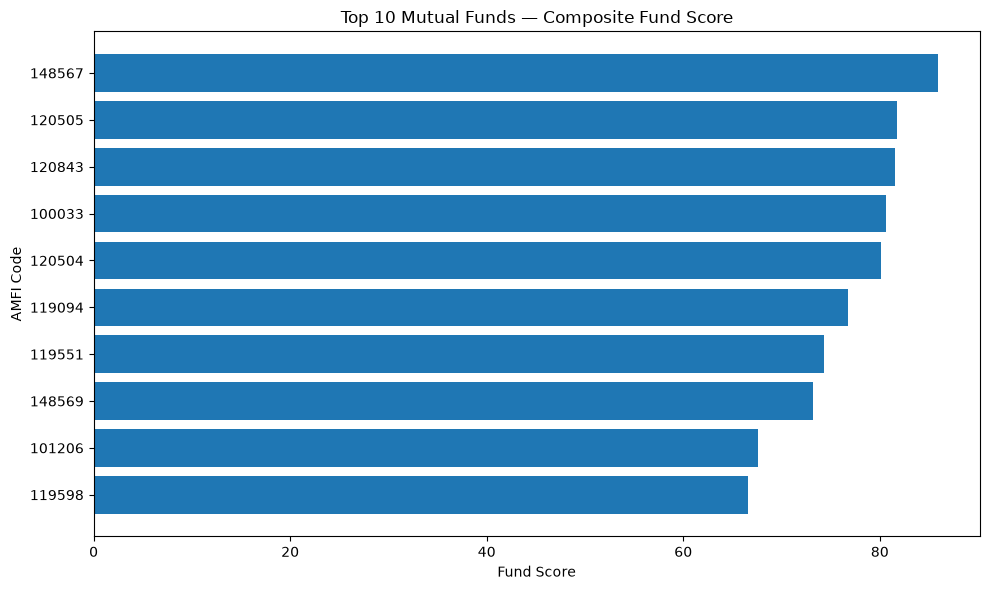

In [136]:
import matplotlib.pyplot as plt

top10 = final_scorecard.head(10).sort_values(
    'fund_score'
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10['amfi_code'].astype(str),
    top10['fund_score']
)

plt.xlabel("Fund Score")
plt.ylabel("AMFI Code")
plt.title("Top 10 Mutual Funds — Composite Fund Score")

plt.tight_layout()
plt.show()

In [137]:
final_scorecard.to_csv(
    "C:/MutualfundProject/data/processed/performance_Analytics_CSV_file/07_fund_scorecard.csv",
    index=False
)

In [138]:
##Benchmark comparison chart — plot top 5 funds vs Nifty 50 and Nifty 100 over 3 years. Compute tracking error = std(fund_return − 
##benchmark_return) × √252.

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scorecard = pd.read_csv(
    "C:/MutualfundProject/data/processed/performance_Analytics_CSV_file/07_fund_scorecard.csv"
)

top5 = scorecard.sort_values(
    'overall_rank'
).head(5)

top5[['overall_rank', 'amfi_code', 'fund_score']]

,overall_rank,amfi_code,fund_score
0,1,148567,85.90
1,2,120505,81.79
2,3,120843,81.54
3,4,100033,80.64
4,5,120504,80.13


In [140]:
top5['amfi_code'] = top5['amfi_code'].astype(str)

In [141]:
fund_returns = pd.read_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/01_nav_daily_returns.csv"
)

fund_returns['Date'] = pd.to_datetime(
    fund_returns['date']
)

fund_returns['amfi_code'] = (
    fund_returns['amfi_code'].astype(str)
)

fund_returns = fund_returns[
    fund_returns['amfi_code'].isin(
        top5['amfi_code']
    )
].copy()

In [142]:
nifty50 = pd.read_csv(
    "C:/MutualFundProject/data/raw/nifty50.csv"
)

nifty100 = pd.read_csv(
    "C:/MutualFundProject/data/raw/nifty100.csv"
)

In [143]:
nifty50['date'] = pd.to_datetime(
    nifty50['date']
)

nifty100['date'] = pd.to_datetime(
    nifty100['date']
)

In [144]:
nifty50['close_value'] = pd.to_numeric(
    nifty50['close_value'],
    errors='coerce'
)

nifty100['close_value'] = pd.to_numeric(
    nifty100['close_value'],
    errors='coerce'
)

In [145]:
nifty50 = nifty50.sort_values('date')

nifty50['nifty50_return'] = (nifty50['close_value'].pct_change()
                            )

In [146]:
nifty100 = nifty100.sort_values('date')

nifty100['nifty100_return'] = (
    nifty100['close_value'].pct_change()
)

In [147]:
nifty50 = nifty50.dropna(
    subset=['nifty50_return']
)

nifty100 = nifty100.dropna(
    subset=['nifty100_return']
)

In [148]:
fund_returns['date'] = pd.to_datetime(
    fund_returns['date'],
    errors='coerce'
)

nifty50['date'] = pd.to_datetime(
    nifty50['date'],
    errors='coerce'
)

nifty100['date'] = pd.to_datetime(
    nifty100['date'],
    errors='coerce'
)

In [149]:
print(fund_returns['date'].dtype)
print(nifty50['date'].dtype)
print(nifty100['date'].dtype)

datetime64[us]
datetime64[us]
datetime64[us]


In [150]:
end_date = min(
    fund_returns['date'].max(),
    nifty50['date'].max(),
    nifty100['date'].max()
)

start_date = end_date - pd.DateOffset(years=3)

print("Start date:", start_date)
print("End date:", end_date)

Start date: 2023-05-29 00:00:00
End date: 2026-05-29 00:00:00


In [151]:
fund_returns = fund_returns[
    (fund_returns['date'] >= start_date) &
    (fund_returns['date'] <= end_date)
].copy()

In [152]:
nifty50 = nifty50[
    (nifty50['date'] >= start_date) &
    (nifty50['date'] <= end_date)
].copy()

nifty100 = nifty100[
    (nifty100['date'] >= start_date) &
    (nifty100['date'] <= end_date)
].copy()

In [153]:
benchmarks = nifty50[
    ['date', 'nifty50_return']
].merge(
    nifty100[
        ['date', 'nifty100_return']
    ],
    on='date',
    how='inner'
)

benchmarks.head()

,date,nifty50_return,nifty100_return
0,2023-05-29,0.005302,0.000667
1,2023-05-30,-0.005287,-0.001613
2,2023-05-31,-0.003343,-0.003352
3,2023-06-01,-0.004093,-0.007142
4,2023-06-02,0.000945,0.003643


In [154]:
comparison = fund_returns.merge(
    benchmarks,
    on='date',
    how='inner'
)

In [155]:
comparison['excess_nifty100'] = (
    comparison['daily_return']
    - comparison['nifty100_return']
)

In [156]:
comparison['excess_nifty50'] = (
    comparison['daily_return']
    - comparison['nifty50_return']
)

In [157]:
tracking_error = (
    comparison
    .groupby('amfi_code')
    .agg(
        tracking_error_nifty50=(
            'excess_nifty50',
            'std'
        ),
        tracking_error_nifty100=(
            'excess_nifty100',
            'std'
        )
    )
    .reset_index()
)

In [158]:
tracking_error[
    'tracking_error_nifty50'
] *= np.sqrt(252)

tracking_error[
    'tracking_error_nifty100'
] *= np.sqrt(252)

In [159]:
tracking_error = tracking_error.merge(
    top5[
        ['amfi_code', 'overall_rank', 'fund_score']
    ],
    on='amfi_code',
    how='inner'
)

tracking_error = tracking_error.sort_values(
    'overall_rank'
)

In [160]:
tracking_error = tracking_error.round({
    'tracking_error_nifty50': 4,
    'tracking_error_nifty100': 4,
    'fund_score': 2
})

tracking_error

,amfi_code,tracking_error_nifty50,tracking_error_nifty100,overall_rank,fund_score
4,148567,0.1918,0.1879,1,85.90
2,120505,0.2283,0.2325,2,81.79
3,120843,0.2049,0.2064,3,81.54
0,100033,0.2281,0.2248,4,80.64
1,120504,0.1884,0.1873,5,80.13


In [161]:
fund_growth = (
    comparison
    .sort_values(['amfi_code', 'date'])
    .copy()
)

fund_growth['growth'] = (
    fund_growth
    .groupby('amfi_code')['daily_return']
    .transform(lambda x: (1 + x).cumprod())
)

In [162]:
nifty50_chart = benchmarks.sort_values(
    'date'
).copy()

nifty50_chart['nifty50_growth'] = (
    (1 + nifty50_chart['nifty50_return']).cumprod()
)

In [163]:
nifty50_chart['nifty100_growth'] = (
    (1 + nifty50_chart['nifty100_return']).cumprod()
)

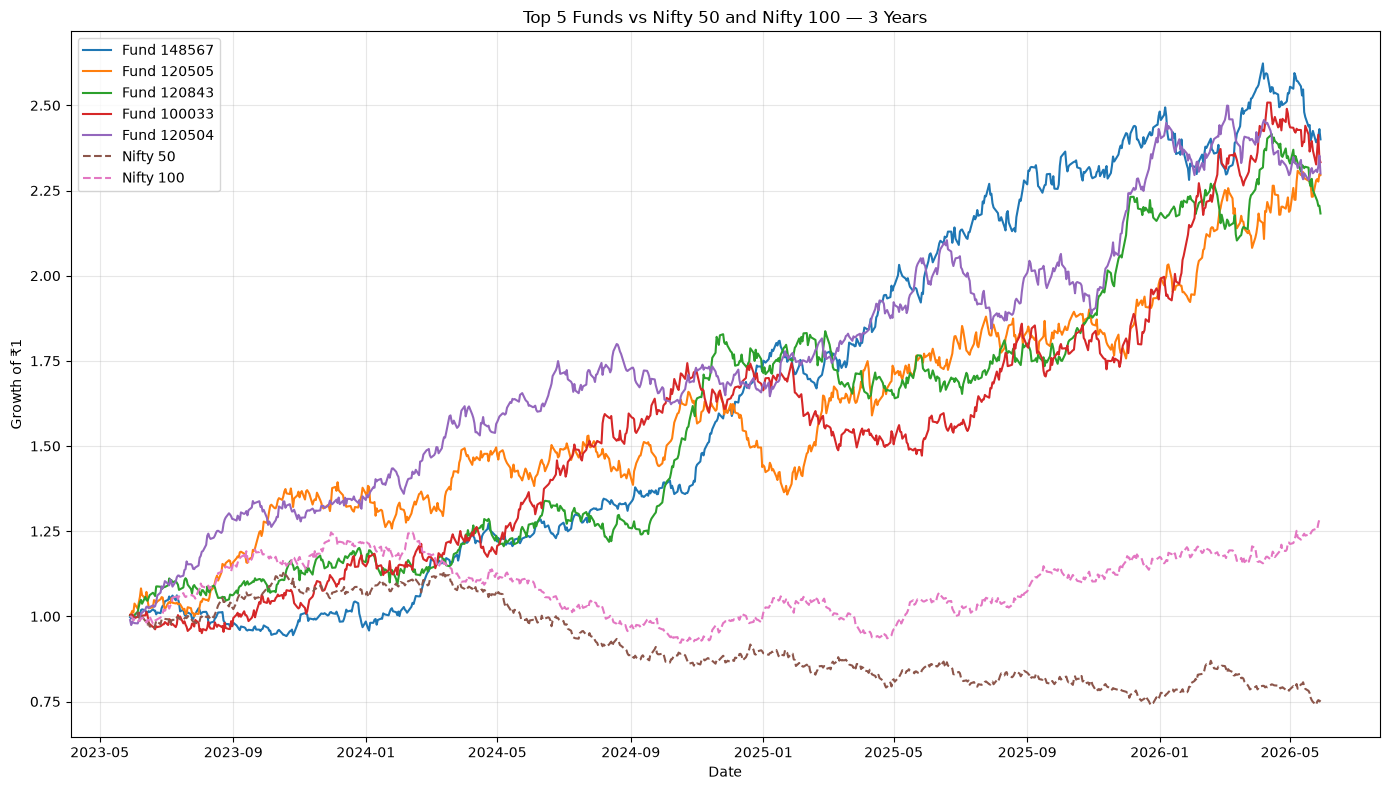

In [164]:
plt.figure(figsize=(14, 8))

for scheme in top5['amfi_code']:

    data = fund_growth[
        fund_growth['amfi_code'] == scheme
    ]

    plt.plot(
        data['date'],
        data['growth'],
        label=f"Fund {scheme}"
    )

plt.plot(
    nifty50_chart['date'],
    nifty50_chart['nifty50_growth'],
    linestyle='--',
    label='Nifty 50'
)

plt.plot(
    nifty50_chart['date'],
    nifty50_chart['nifty100_growth'],
    linestyle='--',
    label='Nifty 100'
)

plt.title(
    "Top 5 Funds vs Nifty 50 and Nifty 100 — 3 Years"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹1")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

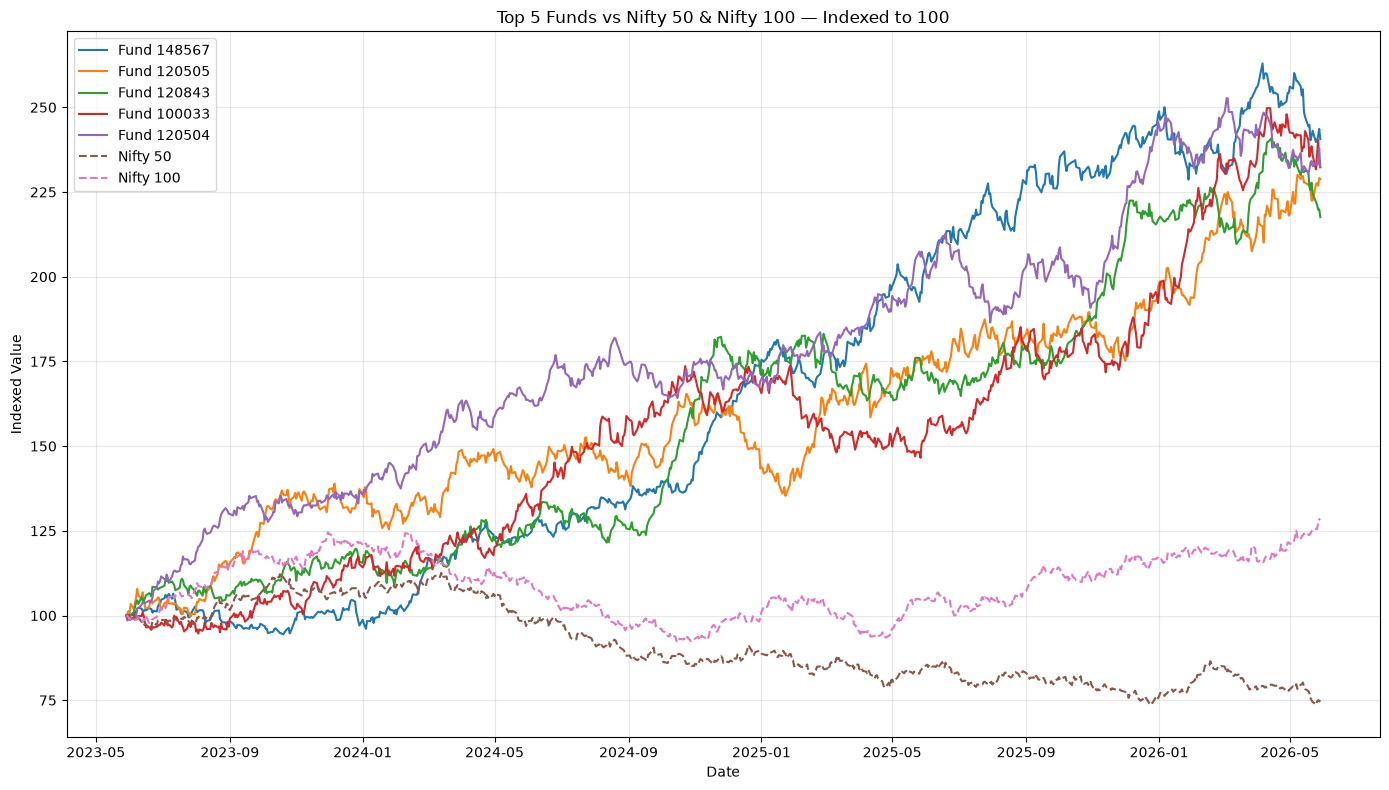

In [165]:
plt.figure(figsize=(14, 8))

for scheme in top5['amfi_code']:

    data = fund_growth[
        fund_growth['amfi_code'] == scheme
    ].copy()

    data['indexed'] = (
        data['growth'] /
        data['growth'].iloc[0]
    ) * 100

    plt.plot(
        data['date'],
        data['indexed'],
        label=f"Fund {scheme}"
    )

benchmark_start = nifty50_chart.iloc[0]

nifty50_indexed = (
    nifty50_chart['nifty50_growth'] /
    nifty50_chart['nifty50_growth'].iloc[0]
) * 100

nifty100_indexed = (
    nifty50_chart['nifty100_growth'] /
    nifty50_chart['nifty100_growth'].iloc[0]
) * 100

plt.plot(
    nifty50_chart['date'],
    nifty50_indexed,
    linestyle='--',
    label='Nifty 50'
)

plt.plot(
    nifty50_chart['date'],
    nifty100_indexed,
    linestyle='--',
    label='Nifty 100'
)

plt.title(
    "Top 5 Funds vs Nifty 50 & Nifty 100 — Indexed to 100"
)

plt.xlabel("Date")
plt.ylabel("Indexed Value")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [166]:
plt.savefig(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/reports/top5_vs_nifty_benchmark_3yr.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [167]:
tracking_error.to_csv(
    "C:/MutualFundProject/data/processed/performance_Analytics_CSV_file/08_top5_tracking_error.csv",
    index=False
)